In [70]:
import pandas as pd
import numpy as np
import requests
import re
from pprint import pprint
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None) # no-limit row display in df, remember to .head()

In [71]:
import sys
sys.executable # checking the venv

'/Users/mac/rec_analysis/venv/bin/python'

-------

## Fairness in recidivism risk assesment - PART 1:
### Analysis made using the Catalan Prison Recidivism Rate DS and Eticas RisCanvi audit conclusions.

**Part 1 (pre-processing, EDA):**
* variable exploration and standard pre-processing (checking for leakage variables, handling nulls etc.)
* historical data EDA for distribution and proxy bias (benchmarks for further comparison of results with own models)<br>

**Part 2 (standard modelling):**
* risk assesment using standard models (regression, tree-based) - fairness, bias, interpretability tradeoffs in the light of ProPublica RisCanvi audit (conclusions and metrics comparison)<br>
* fairness analysis on standard models (input modification experimenting, post-processing fairness augmentation methods)

**Part 3 (foundation and Corel models - experimental):**
* using rule-list models (ex. CORELS) for risk assesment - accuracy and fairness overview
* data preparation for ICL modeling (pre-processing methods to enhance fairness of in-context learning (ICL), ex. uncertainty selection)
* using foundation models (ex. TabPFN v2 (ICL)) for risk assesment - accuracy and fairness overview<br>

**Part 4 (Monte Carlo alternative outcome error evaluation, conlusions):**
* rating injustice score over different models knowing the cost of alternative scenario (injustice score)
* conclusion: tool comparison for recidivism risk assesment (data flexibility, accuracy/fairness tradeoff). How rule-list based and ICL foundation models for criminal risk assesment affect bias and interpretability and overall justice metrics.
* future of recidivsm risk assesment

In [4]:
%cd '/Users/mac/rec_analysis'

/Users/mac/rec_analysis


In [58]:
df_all = pd.read_csv('data/CPRS.csv')

# Variable exploration:

Using only RisCanvi substitue features (Eticas audit recomendations p. 57). Only first complete violent recidivism screening (**RisCanvi-C**) is taken into account.

In [59]:
riscanvi_features = ['V72_DELICTEPBVIOL','V139_EDAT_DELICTEPBASE','V76_R3C_F03_IntoxicacioDelicteBase','V77_R3C_F04_VictimesLesions','V86_DURADA_PENA_RisCanvi',
                     'V78_R3C_F07_HistoriaViolencia','V79_R3C_F08_IniciActivitatDelictiva','V80_R3C_F09_IncrementGravetatDelictes','V104_R3C_F10_ConflictesAmbInterns',
                     'V105_R3C_F11_IncomplimentsMesures','V106_R3C_F12_ExpedientsDisciplinaris','V107_R3C_F13_EvasionsFugues','V108_R3C_F14_RegressioGrau','V109_R3C_F15_TrencamentPermisos',
                     'V29_R3C_F16_DesajustInfantil','V30_R3C_F18_NivellEducatiu','V31_R3C_F19_ProblemesOcupacio','V32_R3C_F20_MancaRecursosEconomics','V33_R3C_F21_AbsenciaPlansFutur','V34_R3C_F22_AntecedentsFamilia',
                     'V35_R3C_F23_SocialitzacioProblematica','V36_R3C_F24_MancaSuportFamiliarSocial','V37_R3C_F25_PertinençaBandes','V38_R3C_F26_PertinençaGrupRisc','V39_R3C_F27_RolDelictiuDestacat',
                     'V40_R3C_F28_VictimaVIGE','V41_R3C_F29_CarreguesFamiliars','V42_R3C_F30_ConsumDrogues','V43_R3C_F31_ConsumAlcohol','V44_R3C_F32_TranstornMentalSever','V45_R3C_F33_ComportamentSexualRisc',
                     'V46_R3C_F34_RespostaLimitadaTractament','V47_R3C_F35_TranstornPersonalitat','V48_R3C_F36_PobreAfrontamentEstres','V49_R3C_F37_IntentsAutolesio','V50_R3C_F38_ActitudsProcriminals','V51_R3C_F39_BaixCI',
                     'V52_R3C_F40_Temeritat','V53_R3C_F41_Impulsivitat','V54R3C_F42_Hostilitat','V55_R3C_F43_Irresponsabilitat','V205_R1_REVI','REINCIDENCIA_VIOLENTA']

In [60]:
df = df_all[riscanvi_features].dropna()

In [209]:
df_all = df_all.loc[df.index]

In [61]:
df['REINCIDENCIA_VIOLENTA'] = df['REINCIDENCIA_VIOLENTA'].replace(2, 0)
df_all['REINCIDENCIA_VIOLENTA'] = df_all['REINCIDENCIA_VIOLENTA'].replace(2, 0)
df['REINCIDENCIA_VIOLENTA'].value_counts()

REINCIDENCIA_VIOLENTA
0    1920
1     102
Name: count, dtype: int64

In [415]:
df.to_csv('data/df.csv', index=False)
df_all.to_csv('data/df_all.csv', index=False)

### Correlation matrix:

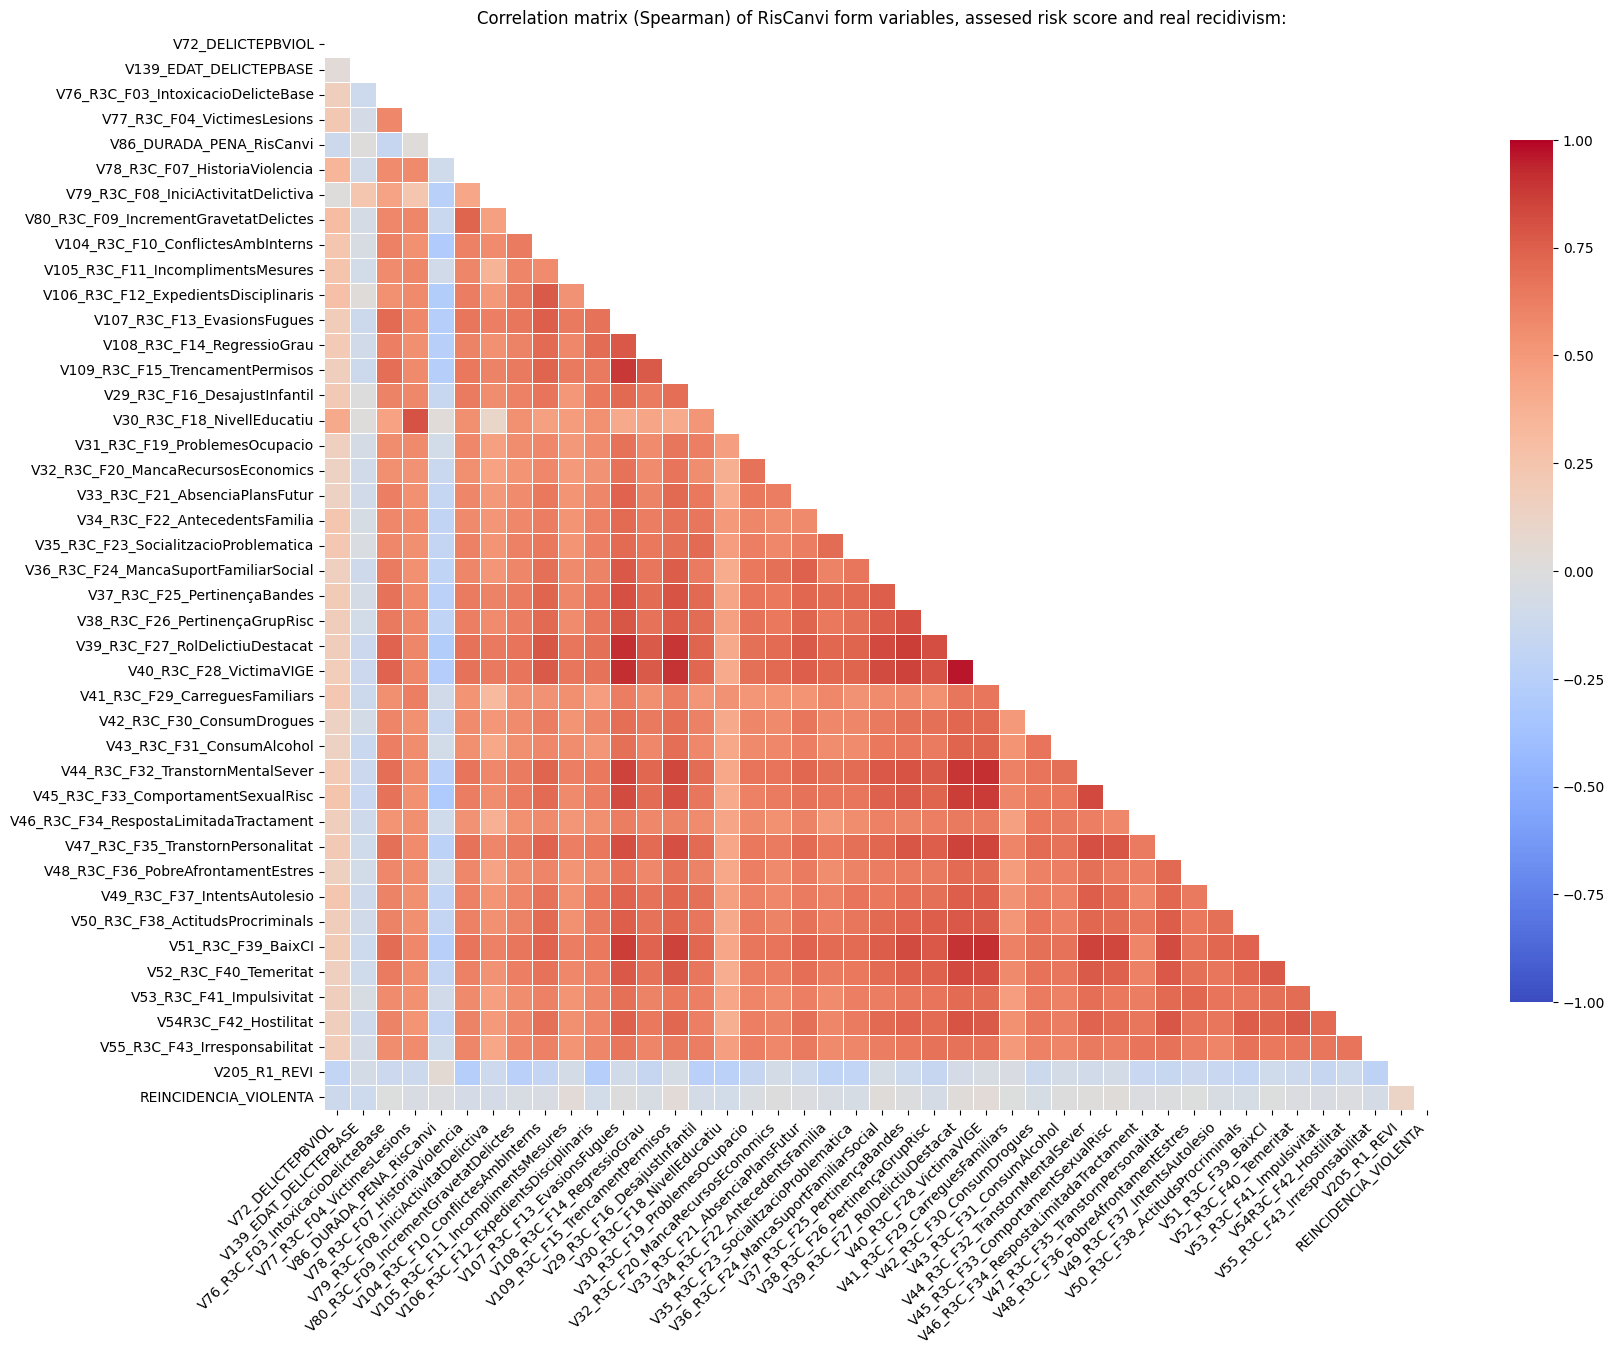

In [418]:
corr_matrix = df.corr(method='spearman') 

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix, 
    mask=mask,          
    annot=False,        
    fmt=".2f",        
    cmap='coolwarm',   
    vmax=1,             
    vmin=-1,     
    center=0,       
    linewidths=.5,     
    cbar_kws={"shrink": .8} )

plt.title('Correlation matrix (Spearman) of RisCanvi form variables, assesed risk score and real recidivism:')
plt.xticks(rotation=45, ha='right') 
plt.show()

In [419]:
corr_matrix['V205_R1_REVI'].abs().sort_values(ascending=False) # correlation absolute values of RisCanvi-C based assesed risk factor to real target class and X variables

V205_R1_REVI                              1.000000
V78_R3C_F07_HistoriaViolencia             0.265597
V106_R3C_F12_ExpedientsDisciplinaris      0.264055
V80_R3C_F09_IncrementGravetatDelictes     0.241701
V29_R3C_F16_DesajustInfantil              0.240429
V30_R3C_F18_NivellEducatiu                0.230325
V55_R3C_F43_Irresponsabilitat             0.212386
V34_R3C_F22_AntecedentsFamilia            0.195938
V72_DELICTEPBVIOL                         0.185644
V35_R3C_F23_SocialitzacioProblematica     0.182561
V104_R3C_F10_ConflictesAmbInterns         0.179124
V50_R3C_F38_ActitudsProcriminals          0.171423
V38_R3C_F26_PertinençaGrupRisc            0.163598
V53_R3C_F41_Impulsivitat                  0.161512
V31_R3C_F19_ProblemesOcupacio             0.159335
V108_R3C_F14_RegressioGrau                0.157053
V47_R3C_F35_TranstornPersonalitat         0.151588
V46_R3C_F34_RespostaLimitadaTractament    0.146448
V49_R3C_F37_IntentsAutolesio              0.145934
V76_R3C_F03_IntoxicacioDelicteB

### Correlation-related conclusions:
Despite **high-level correlations between human-input form (*X*) variables** (which may indicate the presence of proxy variables), **the correlation value of assesed risk score to real target (violent recidivism) is only ~0.12.**. This suggests that the linear association between the risk score and observed recidivism is relatively weak when measured using Pearson correlation.<br> Moreover, close to 0 correlation values of risk score to some X variables is observed, which means there are also little linear explanation in the input variables for these RisCanvi outputs.<br>For a full conclusion, further investigation is needed.

# EDA and distribution analysis:
Checking for potential historical data biases present in data and RisCanvi risk scores (distribution bias)

------

**Scores calibration**:<br>
First, I'm checking if the proportion of recidivsm increases with higher scores (globally and subgroup-divided).

Global calibration:

In [280]:
df_all.groupby('V205_R1_REVI')['REINCIDENCIA_VIOLENTA'].mean()

V205_R1_REVI
1.0    0.037061
2.0    0.066456
3.0    0.142857
Name: REINCIDENCIA_VIOLENTA, dtype: float64

**Subgroup-divided calibration:**

In [420]:
from utils import check_score_consistency # own function checking score consistency among selected variables

In [401]:
segments_to_test = ['V18_SEXE','V19_ESTRANGERS','V30_R3C_F18_NivellEducatiu', 'V27_EDAT_PB_AGRUPADA'] # bias-prone features
report = check_score_consistency(df_all, 'V205_R1_REVI', 'REINCIDENCIA_VIOLENTA', subgroups=segments_to_test)

print('Grouped score calibration (showing only subgroups with decalibrated score):')
display(report[report['consistent'] == False])

Grouped score calibration (showing only subgroups with decalibrated score):


,subgroup,col,val,consistent,violations_count,max_drop,trend_values,counts
2,V19_ESTRANGERS == 2,V19_ESTRANGERS,2.0,False,2,-0.025816,"{1.0: 0.05102, 2.0: 0.04854, 3.0: 0.02273}","{1.0: 588, 2.0: 103, 3.0: 44}"
4,V30_R3C_F18_NivellEducatiu == 9,V30_R3C_F18_NivellEducatiu,9.0,False,2,-0.027778,"{1.0: 0.03406, 2.0: 0.02778, 3.0: 0.0}","{1.0: 734, 2.0: 72, 3.0: 40}"


**Conclusion:** even though Eticas audit conclusions didn't include **foreign status** (`V19_ESTRANGERS == 2`)as a discriminative feature, it has been shown here, that it's **one of few subgroups with decalibrated score values**. Meaning as the score values in the subgroup go up, the real recidivism rate falls. That may indicate replicating the input data bias, especially that resulting from human-input features (ex. higher unemployment, lower economical status, lower education level) or base rate differences in historical data.<br><br>I ignore unknown education level (`V30_R3C_F18_NivellEducatiu == 9`) subgroup, because among this group there are no real recidivist with the highest score and its potential bias interpretation is complex and unclear.

---------------

**Input features distribution shift (foreign status)**:<br>
Checking, if the distributions of features (especially those human-filled) differ in foreigners.<br><br>**If true for a part of the features**, may indicate (keeping in mind the decalibration of scores for foreigners) that foreigners get high scores not for violence, but for a specific sociodemographic profile, which RisCanvi treats as high-risk. However, in their case it may not correlate with violent recidivism as strongly as in general population. During modeling, coefficient weight division (peronalization for different subgroups) regarding these features should be considered.<br><br>**If false for all features**, the differences in calibration may come from lower violent recidivism rates in foreigners (which was proved to be true in Eticas audit) connected with high FP rate count in RisCanvi scoring.

In [426]:
from utils import compare_features # own function checking feature value distribution for different subgroups

In [424]:
features = list(df.columns[:-2])
features.append('V27_EDAT_PB_AGRUPADA')
features.remove('V139_EDAT_DELICTEPBASE')
diff_report = compare_features(df_all, 'V19_ESTRANGERS', 2, features)
diff_report

,feature,p_value,is_different,foreigner,others
0,V72_DELICTEPBVIOL,3.320433e-14,True,"{2: 0.75, 1: 0.24, 9: 0.0}","{2: 0.59, 1: 0.41}"
1,V76_R3C_F03_IntoxicacioDelicteBase,3.109485e-92,True,"{2: 0.6, 9: 0.32, 1: 0.07}","{2: 0.84, 1: 0.15, 9: 0.01}"
2,V77_R3C_F04_VictimesLesions,3.649736e-94,True,"{9: 0.32, 2: 0.31, 0: 0.24, 1: 0.13}","{0: 0.45, 2: 0.34, 1: 0.2, 9: 0.01}"
3,V86_DURADA_PENA_RisCanvi,9.423642e-06,True,"{1.0: 0.63, 2.0: 0.31, 3.0: 0.06}","{1.0: 0.59, 2.0: 0.29, 3.0: 0.13}"
4,V78_R3C_F07_HistoriaViolencia,2.334493e-96,True,"{2: 0.57, 9: 0.32, 1: 0.11}","{2: 0.71, 1: 0.28, 9: 0.01}"
5,V79_R3C_F08_IniciActivitatDelictiva,3.478098e-93,True,"{2: 0.53, 9: 0.32, 3: 0.12, 1: 0.03}","{2: 0.66, 3: 0.27, 1: 0.06, 9: 0.01}"
6,V80_R3C_F09_IncrementGravetatDelictes,1.976643e-93,True,"{2: 0.56, 9: 0.32, 1: 0.12}","{2: 0.71, 1: 0.28, 9: 0.01}"
7,V104_R3C_F10_ConflictesAmbInterns,8.537559e-88,True,"{3: 0.61, 9: 0.32, 2: 0.04, 1: 0.03, 4: 0.0}","{3: 0.87, 2: 0.07, 1: 0.04, 9: 0.01, 4: 0.01}"
8,V105_R3C_F11_IncomplimentsMesures,3.125022e-91,True,"{3: 0.54, 9: 0.32, 2: 0.1, 1: 0.03, 4: 0.0}","{3: 0.7, 2: 0.21, 1: 0.05, 4: 0.03, 9: 0.01}"
9,V106_R3C_F12_ExpedientsDisciplinaris,7.228535e-89,True,"{3: 0.53, 9: 0.32, 2: 0.11, 1: 0.04, 4: 0.0}","{3: 0.74, 2: 0.2, 1: 0.05, 9: 0.01, 4: 0.01}"


**Final verification**:<br>
Filtering inmates with missing data ('*9*' value) in human-filled features. Checking if decalibration increases.

In [392]:
form_features = ['V76_R3C_F03_IntoxicacioDelicteBase','V77_R3C_F04_VictimesLesions','V78_R3C_F07_HistoriaViolencia','V79_R3C_F08_IniciActivitatDelictiva',
                 'V80_R3C_F09_IncrementGravetatDelictes','V104_R3C_F10_ConflictesAmbInterns','V105_R3C_F11_IncomplimentsMesures','V106_R3C_F12_ExpedientsDisciplinaris',
                 'V107_R3C_F13_EvasionsFugues','V108_R3C_F14_RegressioGrau','V109_R3C_F15_TrencamentPermisos','V29_R3C_F16_DesajustInfantil','V30_R3C_F18_NivellEducatiu',
                 'V31_R3C_F19_ProblemesOcupacio','V32_R3C_F20_MancaRecursosEconomics','V33_R3C_F21_AbsenciaPlansFutur','V34_R3C_F22_AntecedentsFamilia','V35_R3C_F23_SocialitzacioProblematica',
                 'V36_R3C_F24_MancaSuportFamiliarSocial','V37_R3C_F25_PertinençaBandes','V38_R3C_F26_PertinençaGrupRisc','V39_R3C_F27_RolDelictiuDestacat','V40_R3C_F28_VictimaVIGE',
                 'V41_R3C_F29_CarreguesFamiliars','V42_R3C_F30_ConsumDrogues','V43_R3C_F31_ConsumAlcohol','V44_R3C_F32_TranstornMentalSever','V45_R3C_F33_ComportamentSexualRisc',
                 'V46_R3C_F34_RespostaLimitadaTractament','V47_R3C_F35_TranstornPersonalitat','V48_R3C_F36_PobreAfrontamentEstres','V49_R3C_F37_IntentsAutolesio',
                 'V50_R3C_F38_ActitudsProcriminals','V51_R3C_F39_BaixCI','V52_R3C_F40_Temeritat','V53_R3C_F41_Impulsivitat','V54R3C_F42_Hostilitat','V55_R3C_F43_Irresponsabilitat']

In [425]:
df_foreigners = df_all[df_all['V19_ESTRANGERS'] == 2]

report = check_score_consistency(
    df=df_foreigners, 
    score_col='V205_R1_REVI', 
    target_col='REINCIDENCIA_VIOLENTA', 
    counts_threshold=10,
    subgroups=form_features
)

missing_data_rows = report[report['val']==9] # missing data only
global_data_rows = report[report['val']!=9] # global calibration trends for reference

missing_data_rows = missing_data_rows.sort_values(by='max_drop', ascending=True)
global_data_rows = global_data_rows.sort_values(by='max_drop', ascending=True)

print('Score calibration - rows with missing data only:')
display(missing_data_rows)
print('Score calibration - non-missing data only:')
display(global_data_rows)

Score calibration - rows with missing data only:


,subgroup,col,val,consistent,violations_count,max_drop,trend_values,counts
38,V36_R3C_F24_MancaSuportFamiliarSocial == 9,V36_R3C_F24_MancaSuportFamiliarSocial,9,False,2,-0.066667,"{1.0: 0.07292, 2.0: 0.06667, 3.0: 0.0}","{1.0: 192, 2.0: 30, 3.0: 14}"
58,V46_R3C_F34_RespostaLimitadaTractament == 9,V46_R3C_F34_RespostaLimitadaTractament,9,False,2,-0.066667,"{1.0: 0.07254, 2.0: 0.06667, 3.0: 0.0}","{1.0: 193, 2.0: 30, 3.0: 14}"
48,V41_R3C_F29_CarreguesFamiliars == 9,V41_R3C_F29_CarreguesFamiliars,9,False,2,-0.066667,"{1.0: 0.0733, 2.0: 0.06667, 3.0: 0.0}","{1.0: 191, 2.0: 30, 3.0: 14}"
46,V40_R3C_F28_VictimaVIGE == 9,V40_R3C_F28_VictimaVIGE,9,False,2,-0.066667,"{1.0: 0.07292, 2.0: 0.06667, 3.0: 0.0}","{1.0: 192, 2.0: 30, 3.0: 14}"
44,V39_R3C_F27_RolDelictiuDestacat == 9,V39_R3C_F27_RolDelictiuDestacat,9,False,2,-0.066667,"{1.0: 0.0733, 2.0: 0.06667, 3.0: 0.0}","{1.0: 191, 2.0: 30, 3.0: 14}"
42,V38_R3C_F26_PertinençaGrupRisc == 9,V38_R3C_F26_PertinençaGrupRisc,9,False,2,-0.066667,"{1.0: 0.0733, 2.0: 0.06667, 3.0: 0.0}","{1.0: 191, 2.0: 30, 3.0: 14}"
39,V37_R3C_F25_PertinençaBandes == 9,V37_R3C_F25_PertinençaBandes,9,False,2,-0.066667,"{1.0: 0.0733, 2.0: 0.06667, 3.0: 0.0}","{1.0: 191, 2.0: 30, 3.0: 14}"
75,V54R3C_F42_Hostilitat == 9,V54R3C_F42_Hostilitat,9,False,2,-0.066667,"{1.0: 0.0733, 2.0: 0.06667, 3.0: 0.0}","{1.0: 191, 2.0: 30, 3.0: 14}"
36,V35_R3C_F23_SocialitzacioProblematica == 9,V35_R3C_F23_SocialitzacioProblematica,9,False,2,-0.066667,"{1.0: 0.07292, 2.0: 0.06667, 3.0: 0.0}","{1.0: 192, 2.0: 30, 3.0: 14}"
33,V34_R3C_F22_AntecedentsFamilia == 9,V34_R3C_F22_AntecedentsFamilia,9,False,2,-0.066667,"{1.0: 0.0733, 2.0: 0.06667, 3.0: 0.0}","{1.0: 191, 2.0: 30, 3.0: 14}"


Score calibration - non-missing data only:


,subgroup,col,val,consistent,violations_count,max_drop,trend_values,counts
24,V30_R3C_F18_NivellEducatiu == 1,V30_R3C_F18_NivellEducatiu,1,False,1,-0.038462,"{1.0: 0.05521, 2.0: 0.11538, 3.0: 0.07692}","{1.0: 163, 2.0: 26, 3.0: 13}"
15,V106_R3C_F12_ExpedientsDisciplinaris == 3,V106_R3C_F12_ExpedientsDisciplinaris,3,False,1,-0.033333,"{1.0: 0.02295, 2.0: 0.03333, 3.0: 0.0}","{1.0: 305, 2.0: 60, 3.0: 24}"
3,V77_R3C_F04_VictimesLesions == 2,V77_R3C_F04_VictimesLesions,2,False,1,-0.029586,"{1.0: 0.02959, 2.0: 0.0, 3.0: 0.0}","{1.0: 169, 2.0: 42, 3.0: 16}"
40,V37_R3C_F25_PertinençaBandes == 2,V37_R3C_F25_PertinençaBandes,2,False,1,-0.023552,"{1.0: 0.03784, 2.0: 0.01429, 3.0: 0.03571}","{1.0: 370, 2.0: 70, 3.0: 28}"
5,V78_R3C_F07_HistoriaViolencia == 2,V78_R3C_F07_HistoriaViolencia,2,False,1,-0.020979,"{1.0: 0.03636, 2.0: 0.01538, 3.0: 0.04}","{1.0: 330, 2.0: 65, 3.0: 25}"
62,V48_R3C_F36_PobreAfrontamentEstres == 3,V48_R3C_F36_PobreAfrontamentEstres,3,False,1,-0.015411,"{1.0: 0.04571, 2.0: 0.0303, 3.0: 0.03846}","{1.0: 350, 2.0: 66, 3.0: 26}"
51,V43_R3C_F31_ConsumAlcohol == 3,V43_R3C_F31_ConsumAlcohol,3,False,1,-0.013129,"{1.0: 0.04298, 2.0: 0.02985, 3.0: 0.03704}","{1.0: 349, 2.0: 67, 3.0: 27}"
41,V38_R3C_F26_PertinençaGrupRisc == 2,V38_R3C_F26_PertinençaGrupRisc,2,False,1,-0.012784,"{1.0: 0.02841, 2.0: 0.01562, 3.0: 0.03846}","{1.0: 352, 2.0: 64, 3.0: 26}"
28,V31_R3C_F19_ProblemesOcupacio == 3,V31_R3C_F19_ProblemesOcupacio,3,False,1,-0.012632,"{1.0: 0.02614, 2.0: 0.05263, 3.0: 0.04}","{1.0: 306, 2.0: 57, 3.0: 25}"
13,V105_R3C_F11_IncomplimentsMesures == 3,V105_R3C_F11_IncomplimentsMesures,3,False,1,-0.012392,"{1.0: 0.03607, 2.0: 0.04688, 3.0: 0.03448}","{1.0: 305, 2.0: 64, 3.0: 29}"


**Conclusion**: for foreign inmates where the human evaluator was unable to determine the variable (entered '*9*'), RisCanvi scores rise higher than in global population (decalibration trend increases), even though their actual recidivism rate drops to zero as their score increases.

----

**Foreigner decalibration: final conclusions – key factors contributing to the decalibration of scores for foreigners:**

* **Ignoring variable intersectionality** - RisCanvi systematically overestimates the risk for foreigners because it fails to account for intersectional effects (e.g., age x origin). The demographics of this group are heavily skewed towards the youngest category (there are almost no older inmates among foreigners, and the vast majority belong to the youngest cohort), which the system penalizes by default. The model fails to recognize that age within the foreign subpopulation carries a different predictive weight than in the general population, resulting in an unjustified elevation of the risk score.

* **Informative Missingness (MNAR) and proxy discrimination (human-assessed features)** - subjective interview features such as employment issues (`V31_R3C_F19_ProblemesOcupacio`), lack of economic resources (`V32_R3C_F20_MancaRecursosEconomics`), absence of future plans (`V33_R3C_F21_AbsenciaPlansFutur`), and family crime history (`V34_R3C_F22_AntecedentsFamilia`) exhibit missing data rates of 30-40% for foreigners, compared to ~1% for Spaniards. The algorithm effectively leverages this missing data (likely resulting from linguistic or systemic barriers) as a hidden identifier of nationality, which constitutes proxy discrimination. Ultimately, the algorithm **punishes individuals for the evaluator's inability to fill out the form**.
<br><br>
These findings prove that relying solely on post-hoc fairness augmentation is insufficient. **RisCanvi requires fundamental changes in input data selection or a completely revised imputation/coefficient assignment methodology**. Sticking to the current data pipeline means we will inevitably encounter the same structural biases, even if the final scoring decalibration is somehow manually fixed.

--------

**Input variables distribution bias**:<br>
I'm checking the class distributions, representation and base rates for RisCanvi scores (False Positives - focused).<br>

**Continouous numerical variable (age):**

In [388]:
print('Mean values of continouous variables grouped into assesed score and real class:\n')
df[['V139_EDAT_DELICTEPBASE','REINCIDENCIA_VIOLENTA','V205_R1_REVI']].groupby(['REINCIDENCIA_VIOLENTA','V205_R1_REVI']).mean()

Mean values of continouous variables grouped into assesed score and real class:



V139_EDAT_DELICTEPBASE
REINCIDENCIA_VIOLENTA V205_R1_REVI                        
0                     1.0                        38.365969
                      2.0                        37.322034
                      3.0                        34.652778
1                     1.0                        31.403509
                      2.0                        34.857143
                      3.0                        32.958333

-----

**Categorical variables:**<br>
Calculating false positives overrepresentations for variable classes (*x*). The formula would be:

$$
\text{bias\_ratio}(x)=
\frac{P(\text{score}=3 \mid \text{real}=0,\ \text{value}=x)}
     {P(\text{score}=3 \mid \text{real}=0)}
$$

In [432]:
df_long = df.melt(
    id_vars=['REINCIDENCIA_VIOLENTA','V205_R1_REVI'],
    value_vars=riscanvi_features,
    var_name='feature',
    value_name='value'
)

bias_table = (
    df_long
    .groupby(['feature','value','REINCIDENCIA_VIOLENTA','V205_R1_REVI'])
    .size()
    .reset_index(name='count')
)

bias_table['pct'] = (
    bias_table.groupby(['feature','value','REINCIDENCIA_VIOLENTA'])['count']
    .transform(lambda x: x/x.sum())
)

baseline = (
    df.groupby(['REINCIDENCIA_VIOLENTA','V205_R1_REVI'])
    .size()
    .groupby(level=0)
    .transform(lambda x: x/x.sum())
    .rename('baseline')
    .reset_index()
)

bias_table = bias_table.merge(
    baseline,
    on=['REINCIDENCIA_VIOLENTA','V205_R1_REVI']
)

bias_table['bias_ratio'] = bias_table['pct'] / bias_table['baseline']

In [433]:
biased_fp = bias_table[
    (bias_table.REINCIDENCIA_VIOLENTA == 0) &
    (bias_table.V205_R1_REVI == 3) &
    (bias_table.bias_ratio > 2) & # over 2x fp overrepresentation for a given x value
    (bias_table['count'] >= 20) # over 20 count (statistical significance)
].sort_values('bias_ratio', ascending=False)

In [434]:
biased_fp[['feature','value','count','bias_ratio']]

,feature,value,count,bias_ratio
834,V50_R3C_F38_ActitudsProcriminals,2.0,45,4.761905
758,V47_R3C_F35_TranstornPersonalitat,1.0,29,4.296296
875,V52_R3C_F40_Temeritat,2.0,24,4.050633
8,V104_R3C_F10_ConflictesAmbInterns,2.0,32,3.987539
928,V54R3C_F42_Hostilitat,2.0,29,3.866667
561,V37_R3C_F25_PertinençaBandes,1.0,25,3.663004
463,V33_R3C_F21_AbsenciaPlansFutur,2.0,35,3.645833
117,V108_R3C_F14_RegressioGrau,2.0,25,3.508772
1049,V79_R3C_F08_IniciActivitatDelictiva,1.0,23,3.445693
646,V42_R3C_F30_ConsumDrogues,2.0,43,3.333333


### We can draw several key conclusions regarding False Positives distribution:
* **Historically, 7.5% of all non-recidivst are given the highest risk scores by RisCanvi** (*real=0 ∩ score=3* baseline). This baseline represents the reference level for analysing potential fairness issues in the allocation of the highest risk category.
* RisCanvi scores **overestimate the risk of violent recidivism in younger inmates** (descending mean age within *real=0* as the score values rise). Also, inmates within the youngest group age of the first conviction (below 16 y.o.) are ~3.5x more likely to receive a FP score than the baseline. 
* It also gives high importance (high-score overrepresentation in *real=0* compared to baseline) to various **human-assesed, cognition-based subjective input features of the inmate**, such as: presence of personality disorder, self-harming behaviors, personality traits of 'recklessness', 'hostility', 'impulsivity', lack of 'future plans' or 'problematic socialization in the family'. There even is an increase in FN representation among inmates with 'poor stress coping skills'. This may create a bias feedback loop. Also, it may **negatively influence the potential for standarizing the assesment outcomes** (which, after all is a main goal of alghoritmic risk assesment), as inputs are human-filled and can vary.
* Factors which may be hard to change for the inmate as **addictions and employment problems** elevate the risk of FN (~3.5x and ~2.5x accordingly), which may be treated as a form of social discrimination.
* Another problem is the potential **institutional bias**: ex. the fact of previous grade regressions or presence of disciplinary records (which can be a part of previous convictions) increases the likelihood of FP score ~3.5x, which - if definitive and causational - may stand against *ne bis in idem* principle.
* Elevated FN representation among the **static factors** values is the most controversial, as these features can't be changed by the inmate, yet - as shows the analysis, as well as the Eticas audit - some of them are highly discriminative in terms of FN outputs overrepresentation. Ex. presence of **'childhood maladjustment'** increases the risk of high score ~3x. The presence of **violence history elevates a chance of FP ~2.5x over baseline** (with very high group count). Even **history of crime among inmate's family members! elevates FN likelihood over 2x** (which may incorporate elements of collective responsibility and is strictly prohibited in European criminal systems, it may also stand against *nullum crimen sine culpa* in the context of penalty severity).

**Underestimated factors in real recidivsm (False Negative - focused distribution analysis):**

An important factor would be checking which variable values importance RisCanvi regularly underestimates (meaning they have high ratio of low scores despite high rate of real recidivism). Most analisies fail to include this perspective, focusing only on False Positive audit. It neither was present in the Eticas RisCanvi audit. The formula is similar to FP-oriented bias:

$$
\text{bias\_ratio}(x) =
\frac{P(\text{score}=1 \mid \text{real}=1,\ \text{value}=x)}
     {P(\text{score}=1 \mid \text{real}=1)}
$$

In [271]:
biased_fn = bias_table[
    (bias_table.REINCIDENCIA_VIOLENTA == 1) &
    (bias_table.V205_R1_REVI == 1) &
    (bias_table.bias_ratio > 1.2) &
    (bias_table['count'] >= 20)
].sort_values('bias_ratio', ascending=False)

In [173]:
biased_fn[['feature','value','count','bias_ratio']]

,feature,value,count,bias_ratio
398,V30_R3C_F18_NivellEducatiu,9.0,25,1.656920
73,V106_R3C_F12_ExpedientsDisciplinaris,3.0,29,1.402560
985,V72_DELICTEPBVIOL,2.0,31,1.353017
1039,V78_R3C_F07_HistoriaViolencia,2.0,31,1.320802
1078,V80_R3C_F09_IncrementGravetatDelictes,2.0,34,1.294513
741,V46_R3C_F34_RespostaLimitadaTractament,3.0,28,1.252632
963,V55_R3C_F43_Irresponsabilitat,3.0,30,1.248470
841,V50_R3C_F38_ActitudsProcriminals,3.0,38,1.214286


### Conclusions regarding the distribution of false negatives
* First of all, it should be noted that **there are significantly less as severe FN-oriented distribution bias in RisCanvi scores compared to FP analysis**. Moreover, the max FN-oriented bias ratio value is ~1.66, while in FP-oriented base rate the max value is over 4.76. This is probably due to higher positive class recall and sensitivity optimization of the algorithm, which has also been demonstrated in the audit. It means that the model appears to favour higher risk assignments, which increases positive recall at the cost of precision. 
* **Among variable values with the highest underestimation of risk are:** unknown education level, lack of disciplinary records, non-violent nature of the current crime, lack of violence history, no increase in the seriousness of crimes, good treatment response and lack of certain negative mental features.
* This indicates, that these features should be treaten with special caution. They may discriminate correctly for a typical inmate, but worse for atypical cases. Even in case of a low score, these values - if present, should be double-checked for credibility, especially that some of the features listed are not prone to discrimination, mainly because they are related strictly to the current crime case.

**Disclaimer**:<br>It should be noted that this analysis **does not assess the statistical significance of the observed patterns**. The results are intended only as an exploratory overview of potential distributional biases and should therefore not be interpreted as definitive causal relationships.<br>
However, on the other hand, we should also take into account that RisCanvi is a **high-risk alghoritm** (AI Act classification), which implies the highest standards of protection. Even slight suspection of fairness violation should be taken seriously. 

-----

### Real class/score to value distributions:

**Distributions of numerical variables (age) divided into classes and RisCanvi scores**:<br>

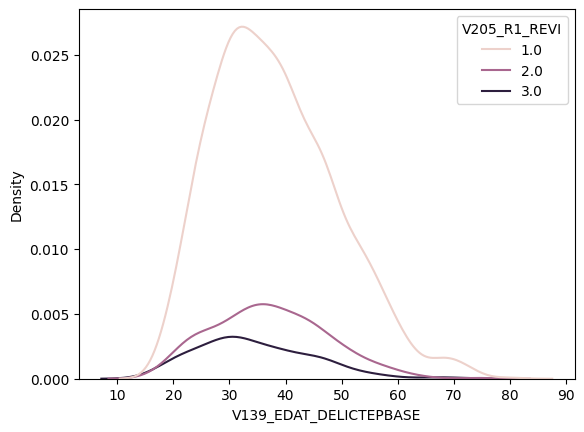

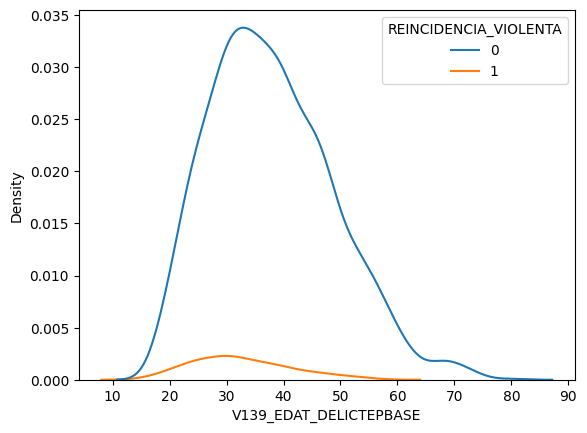

In [186]:
for target in df.columns[-2:]:
        
        for variable in df.columns[:-2]:

            if len(list(df[variable].value_counts()))>5: # continuous numerical variables only
                sns.kdeplot(data=df, x=variable, hue=target)
                plt.show()

In [193]:
df[df['REINCIDENCIA_VIOLENTA']==1]['V139_EDAT_DELICTEPBASE'].describe()

count    102.000000
mean      32.480392
std        8.395815
min       18.000000
25%       26.000000
50%       31.000000
75%       38.000000
max       54.000000
Name: V139_EDAT_DELICTEPBASE, dtype: float64

In [194]:
df[df['V205_R1_REVI']==3]['V139_EDAT_DELICTEPBASE'].describe()

count    168.000000
mean      34.410714
std       10.089617
min       18.000000
25%       27.000000
50%       32.500000
75%       41.000000
max       69.000000
Name: V139_EDAT_DELICTEPBASE, dtype: float64

**Conclusion:** RisCanvi outputs duplicate data distribution bias giving younger inmates higher scores. However, the mean and median values of high scores distribution are a little bit higher than those present in the data.

-------

### Checking for proxy variables related to protected attributes
Assessing whether any protected attribute (A), like gender or nationality, can be inferred directly from RisCanvi features (X). If true, proxy variables may also be a source of indirect discrimination (forbidden, among others, by the Article 14 ECHR).<br><br>
**Methodology:**<br><br>
*A≈f(X)*<br>
Tree-based classifiers are trained to predict chosen A (protected variable); strong predictive performance indicates the presence of multivariate proxy features. Then, permutation importance is applied to the trained model. This allows estimation of the contribution of individual feature to the prediction of the protected attribute (importance).

In [229]:
bias_list = ['V18_SEXE','V19_ESTRANGERS','V23_CATALA','V24_CASTELLA','V26_EXPULSIO']

In [232]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold

In [237]:
print("Mean AUC for predicting protected variables from RisCanvi features\n")

mean_auc_list = []
importances_list = []

for i, protected_variable in enumerate(bias_list, start=1):

    print(f"Loading... {i}/{len(bias_list)}")

    # target
    y = df_all[protected_variable].copy()

    # feature set
    X = df[df.columns[:-2]].copy()

    # remove rare classes
    class_counts = y.value_counts()
    valid_classes = class_counts[class_counts >= 10].index
    valid_idx = y.isin(valid_classes)

    y = y[valid_idx]
    X = X.loc[valid_idx]

    n_classes = y.nunique()

    # encode categorical target
    if y.dtype == "object":
        y = LabelEncoder().fit_transform(y)

    # identify column types
    cat_cols = X.select_dtypes(include=["object", "category"]).columns
    num_cols = X.select_dtypes(exclude=["object", "category"]).columns

    # preprocessing
    preprocess = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
            ("num", "passthrough", num_cols),
        ]
    )

    # model
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=123,
        n_jobs=-1
    )

    pipe = Pipeline([
        ("prep", preprocess),
        ("model", rf)
    ])

    # cross validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
    
    if n_classes <= 2:
        auc_scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
    else:
        auc_scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc_ovr")

    mean_auc = auc_scores.mean()
    mean_auc_list.append(mean_auc)

    # fit model for permutation importance
    pipe.fit(X, y)

    if n_classes <= 2:
        scoring_metric = "roc_auc"
    else:
        scoring_metric = "roc_auc_ovr"
    
    perm = permutation_importance(
        pipe,
        X,
        y,
        n_repeats=10,
        scoring=scoring_metric,
        random_state=123,
        n_jobs=-1
    )

    # feature names after OHE
    feature_names = pipe.named_steps["prep"].get_feature_names_out()

    raw_importances = pd.Series(perm.importances_mean, index=feature_names)

    # aggregate OHE back to original variables
    aggregated_importances = {}

    for col in X.columns:

        matching = [f for f in feature_names if f.startswith(f"cat__{col}_") or f == f"num__{col}"]

        if matching:
            aggregated_importances[col] = raw_importances[matching].sum()

    importances = pd.Series(aggregated_importances).sort_values(ascending=False)

    # strongest proxy candidates
    if mean_auc > 0.6:
        leaking_features = importances[importances > 0.01].index.tolist()
        importances_list.extend(leaking_features)

    print(f"\nVariable: '{protected_variable}', AUC: {mean_auc:.3f}")

    print("Proxy strength:")
    if mean_auc > 0.85:
        print("HIGH proxy signal\n")
    elif mean_auc > 0.75:
        print("MEDIUM proxy signal\n")
    elif mean_auc > 0.7:
        print("WEAK proxy signal\n")
    else:
        print("NO proxy signal\n")

    print("Top 5 proxy candidates:")
    print(importances.head(5))

    print("-------------------------------------------\n")


print(
    "Mean AUC across protected variables:",
    np.array(mean_auc_list).mean().round(3)
)

Mean AUC for predicting protected variables from RisCanvi features

Loading... 1/5

Variable: 'V18_SEXE', AUC: 0.778
Proxy strength:
MEDIUM proxy signal

Top 5 proxy candidates:
V30_R3C_F18_NivellEducatiu     0.120568
V139_EDAT_DELICTEPBASE         0.091762
V86_DURADA_PENA_RisCanvi       0.053116
V72_DELICTEPBVIOL              0.038753
V77_R3C_F04_VictimesLesions    0.010670
dtype: float64
-------------------------------------------

Loading... 2/5

Variable: 'V19_ESTRANGERS', AUC: 0.829
Proxy strength:
MEDIUM proxy signal

Top 5 proxy candidates:
V139_EDAT_DELICTEPBASE                0.089198
V86_DURADA_PENA_RisCanvi              0.037996
V32_R3C_F20_MancaRecursosEconomics    0.020199
V72_DELICTEPBVIOL                     0.014400
V30_R3C_F18_NivellEducatiu            0.010972
dtype: float64
-------------------------------------------

Loading... 3/5

Variable: 'V23_CATALA', AUC: 0.629
Proxy strength:
NO proxy signal

Top 5 proxy candidates:
V139_EDAT_DELICTEPBASE                0.087

**Conclusions:**<br>
Various protected attributes can be inferred from the set of RisCanvi input features. The analysis shows that several protected characteristics can be predicted with relatively high accuracy based solely on the available model inputs (proxy effects arise even though the protected attributes themselves are not included among the model inputs):
* **Gender**: can be derived from the education level, inmate's crime age, length of sentence, crime violence and number of crime victims (mean AUC ~0.78)
* **Foreign status** (Spanish vs. Foreign): the highest proxy from analyzed features (mean AUC ~0.83) can be derived from inmate's crime age, lenth of sentence, economic problems, violent nature of the offence and education level
* **Expulsion case**: Apart from foreign status, RisCanvi can decode the fact if there's an expulsion case towards a foreigner with unregulated stay (mean AUC ~0.78)<br><br>
As seen, the most prone to indirect discrimination features of RisCanvi tend to be: `age`, `education level`, `sentence length`, `economic problems` and `violent nature of the offence`.<br> From a fairness perspective, these variables should be treated with particular caution. In cases where they contribute strongly to predictive performance, during modelling, it's necessary to evaluate if their predictive performance justifies the potential proxy effects they introduce (i.e. the fairness–accuracy trade-off).